# Using PPO to Learn Solar Sail Trajectories

The following code implements a custom Gymnasium environment for a solar sail in low-Earth orbit and trains a PPO model to raise the altitude of the sail to a debris altitude.

In [1]:
%pip install numpy matplotlib seaborn scipy gymnasium stable-baselines3 optuna
%pip install "gymnasium[box2d]" "stable_baselines3[extra]"


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: /home/abish/Vault/projects-gh/machine-learning/.ml/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: /home/abish/Vault/projects-gh/machine-learning/.ml/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os

import gymnasium as gym
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import numpy as np
import optuna
import seaborn as sb
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env 
from stable_baselines3.common.monitor import Monitor, load_results
from stable_baselines3.common.vec_env import SubprocVecEnv

from sailEnv import OrbitRaisingEnv

## Configuration

The following variables control the execution of the algorithm.

In [3]:
INITIAL_SEED = 22                   # used in first training
TUNING_SEED = 222                   # used in hyperparameter tuning
VALIDATION_SEED = 2222              # used when validating tuned models
TRAINING_SEED = 22_222              # used in training the tuned model
TEST_SEED = 222_222                 # used in final test
TIME_STEP =  60                     # seconds per step
REDUCED_EPISODE_TIME = 70*86400     # used in learning, reduced maximum episode time
TOTAL_STEPS = 525_960               # used in learning, equivalent to one year
NO_EPISODES = 30                    # diversity in model learning
N_ENVS = 16                         # vectorization of simulated environments
ALT_THRESHOLD = 500.0               # successful termination
MODEL_NAME = "ppo_orbitRaising"
TUNED_MODEL_NAME = "ppo_orbitRaising_optuna"
ENVIRONMENT_NAME = "OrbitRaising-v1" 

if ENVIRONMENT_NAME not in gym.registry:
    print(f"{ENVIRONMENT_NAME} not found in Gymnasium's registry.")

Checkpoints are stored in `checkpoints/`. Plots are stored in `plots/`. Training data is stored in `trainingData/`.

In [4]:
os.makedirs("checkpoints", exist_ok=True)
os.makedirs("trainingData", exist_ok=True)
os.makedirs("plots", exist_ok=True)

Custom plot styling.

In [5]:
def setStyle(fontsize: int) -> None:
    """
        Sets a custom style to Matplotlib graphs.

        PARAMETERS
        ----------
        fontsize: normal font size
    """
    sb.set_theme(style="whitegrid", palette="muted")
    plt.rcParams.update({
        "font.size": fontsize,
        "axes.titlesize": fontsize+2,
        "axes.labelsize": fontsize,
        "legend.fontsize": fontsize,
        "xtick.labelsize": fontsize-1,
        "ytick.labelsize": fontsize-1,
        "font.family": "STIXGeneral",
        "mathtext.fontset": "stix",
    })

setStyle(14)

## Helpers

`randomRun()` employs a random action space sampling.

In [6]:
def randomRun(seed: int, envName: str=ENVIRONMENT_NAME) -> tuple:
    """
        Employs a random action space sampling against a simulated environment.

        PARAMETERS
        ----------
        seed: initializes RNG
        envName: environment name in Gymnasium's registry

        RETURNS
        ----------
        times: time [s]
        rewards: reward per step
        altDiffs: altitude difference per step [m]
        coneAnglesDeg: cone angle of the sail per step [deg]
        clockAnglesDeg: clock angle of the sail per step [deg]
    """
    env = gym.make(envName, maxTime=30*86400., altThreshold=ALT_THRESHOLD)
    _, info = env.reset(seed=seed)

    # data to store
    times = [info["time"]]
    rewards = []
    altDiffs = [info["altDiff"]]
    coneAngles = [info["coneAngle"]]
    clockAngles = [info["clockAngle"]]

    while True:
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)

        times.append(info["time"])
        rewards.append(reward)
        altDiffs.append(info["altDiff"])
        coneAngles.append(info["coneAngle"])
        clockAngles.append(info["clockAngle"])
        
        if terminated or truncated:
            print(f"Stopped simulating. {'Terminated.' if terminated else 'Truncated.'}")
            break

    env.close()

    times = np.array(times)
    rewards = np.array(rewards)
    altDiffs = np.array(altDiffs)
    coneAnglesDeg = np.rad2deg(coneAngles)
    clockAnglesDeg = np.rad2deg(clockAngles)

    return times, rewards, altDiffs, coneAnglesDeg, clockAnglesDeg

`trainModel()` creates a PPO instance, trains it and saves it.

In [7]:
def trainModel(seed: int, maxEpisodeTime: int=REDUCED_EPISODE_TIME, envName: str=ENVIRONMENT_NAME, totalEps: int=NO_EPISODES, modelName: str=MODEL_NAME, nEnvs: int=N_ENVS, **kwargs) -> None:
    """
        Trains a model against a simulated environment.

        PARAMETERS
        ----------
        seed: initializes RNG
        maxEpisodeTime: maximum time per episode
        envName: environment name in Gymnasium's registry
        totalEps: total number of training episodes
        modelName: name of trained model
        nEnvs: number of vectorized environments
    """
    env = make_vec_env(OrbitRaisingEnv, n_envs=nEnvs, vec_env_cls=SubprocVecEnv, env_kwargs={"maxTime": maxEpisodeTime, "altThreshold": ALT_THRESHOLD}, monitor_dir=f"trainingData/{modelName}", monitor_kwargs={"info_keywords": ("altDiff",)}, seed=seed)

    model = PPO("MlpPolicy", env, seed=seed, device="cpu", **kwargs)
    model.learn(total_timesteps=int(maxEpisodeTime/TIME_STEP)*totalEps, progress_bar=True)
    model.save(modelName)

    env.close()

`testModel()` evaluates the performance of an input model on a certain number of episodes.

In [8]:
def testModel(model, seed: int, envName: str=ENVIRONMENT_NAME, N: int=NO_EPISODES, tuning: bool=True, nEnvs: int=N_ENVS) -> np.ndarray:
    """
        Tests a model against a simulated environment.

        PARAMETERS
        ----------
        model: the trained model
        seed: initializes RNG
        envName: environment name in Gymnasium's registry
        N: number of test episodes
        tuning: whether the function is being called during hyperparameter tuning
        nEnvs: number of vectorized environments

        RETURNS
        ----------
        testRewards: reward per episode
        testLengths: length per episode
    """
    envKwargs = {"maxTime": REDUCED_EPISODE_TIME, "altThreshold": ALT_THRESHOLD} if tuning else {"altThreshold": ALT_THRESHOLD}
    nWorkers = min(nEnvs, N)
    env = make_vec_env(OrbitRaisingEnv, n_envs=nWorkers, vec_env_cls=SubprocVecEnv, env_kwargs=envKwargs, monitor_kwargs={"info_keywords": ("altDiff",)}, seed=seed)
    testRewards = np.zeros(N)
    epRewards = np.zeros(nWorkers)
    testLengths = np.zeros(N)
    epLengths = np.zeros(nWorkers)

    obs = env.reset()
    compCount = 0
    while compCount < N:
        actions, _ = model.predict(obs, deterministic=True)
        obs, rewards, dones, _ = env.step(actions)
        epRewards += rewards
        epLengths += 1
        for i, done in enumerate(dones):
            if done and compCount < N:
                testRewards[compCount] = epRewards[i]
                testLengths[compCount] = epLengths[i]
                compCount += 1
                epRewards[i] = 0
                epLengths[i] = 0

    env.close()

    return testRewards, testLengths

`testFinalModel()` evaluates the performance of the tuned model while storing the desired data features from the best episode.

In [9]:
def testFinalModel(model, seed: int, envName: str=ENVIRONMENT_NAME, tunedModelName: str=TUNED_MODEL_NAME, N: int=NO_EPISODES, nEnvs: int=N_ENVS) -> tuple:
    """
        Tests a tuned model against a simulated environment.

        PARAMETERS
        ----------
        model: the trained model
        seed: initializes RNG
        envName: environment name in Gymnasium's registry
        tunedModelName: tuned model name
        N: number of test episodes
        nEnvs: number of vectorized environments

        RETURNS
        ----------
        testRewards: total reward per episode
        testLengths: length per episode
        bestEpisode = {"time", "reward", "altDiff", "coneAngle", "clockAngle"}
    """
    nWorkers = min(nEnvs, N)
    env = make_vec_env(OrbitRaisingEnv, n_envs=nWorkers, vec_env_cls=SubprocVecEnv, env_kwargs={"altThreshold": ALT_THRESHOLD}, monitor_dir=f"trainingData/{tunedModelName}", monitor_kwargs={"info_keywords": ("altDiff",)}, seed=seed)

    testRewards = np.zeros(N)
    epRewards = np.zeros(nWorkers)
    testLengths = np.zeros(N)
    epLengths = np.zeros(nWorkers, dtype=int)

    emptyHistory = lambda: {"time": [], "reward": [], "altDiff": [], "coneAngle": [], "clockAngle": []}
    history = [emptyHistory() for _ in range(nWorkers)]

    bestReward = -np.inf
    bestEpisode = None
    compCount = 0

    obs = env.reset()
    while compCount < N:
        actions, _ = model.predict(obs, deterministic=True)
        obs, rewards, dones, infos = env.step(actions)
        epRewards += rewards
        epLengths += 1

        for i in range(nWorkers):
            history[i]["time"].append(infos[i]["time"])
            history[i]["reward"].append(rewards[i])
            history[i]["altDiff"].append(infos[i]["altDiff"])
            history[i]["coneAngle"].append(infos[i]["coneAngle"])
            history[i]["clockAngle"].append(infos[i]["clockAngle"])
            if dones[i] and compCount < N:
                testRewards[compCount] = epRewards[i]
                testLengths[compCount] = epLengths[i]
                if epRewards[i] > bestReward:
                    bestReward = epRewards[i]
                    bestEpisode = {k: np.array(v) for k, v in history[i].items()}

                compCount += 1
                epRewards[i] = 0
                epLengths[i] = 0
                history[i] = emptyHistory()

    env.close()

    return testRewards, testLengths, bestEpisode

## Random Policy Baseline

The effect of randomly choosing an action.

In [10]:
randomTimes, randomRewards, randomAltDiffs, randomConeAngles, randomClockAngles = randomRun(seed=INITIAL_SEED)

/home/abish/Vault/projects-gh/machine-learning/.ml/lib/python3.14/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/abish/Vault/projects-gh/machine-learning/.ml/lib/python3.14/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Stopped simulating. Truncated.


### Reward vs. Steps

Shows the evolution of step rewards.

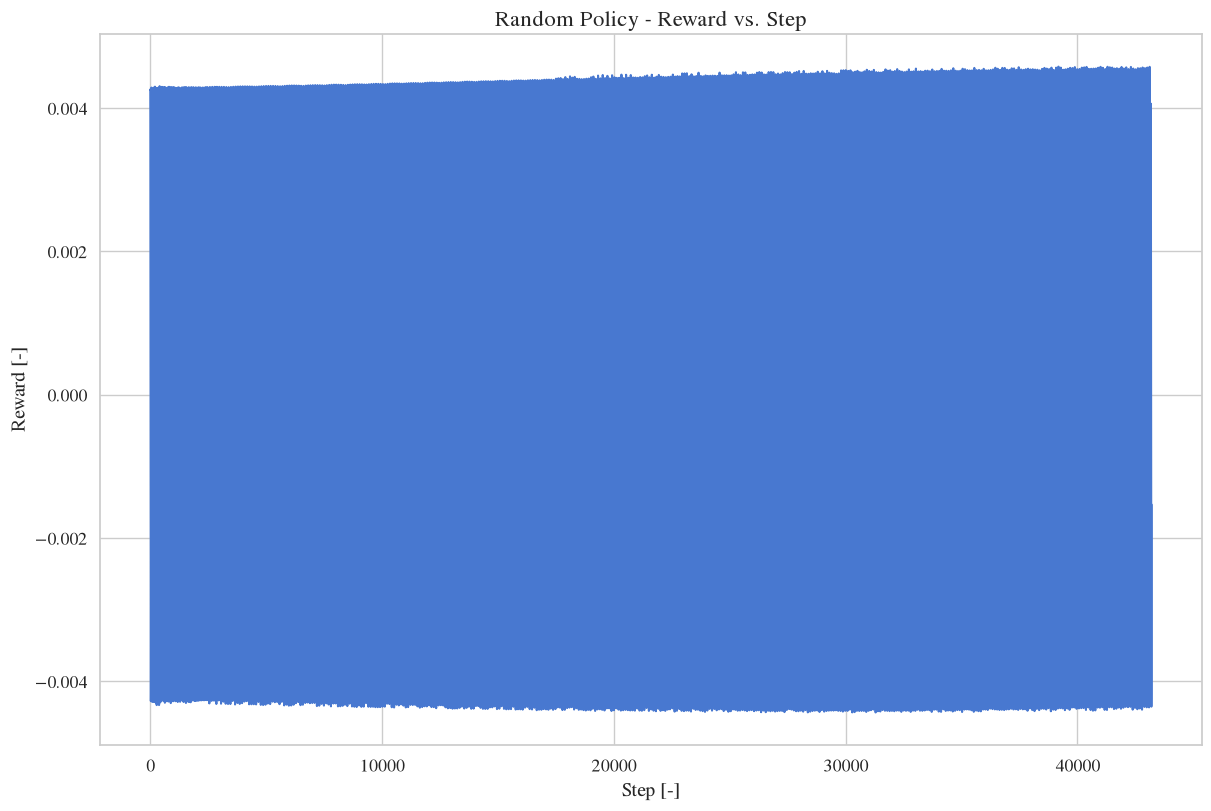

In [11]:
fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)
ax.set_title("Random Policy - Reward vs. Step")
ax.set_xlabel("Step [-]")
ax.set_ylabel("Reward [-]")
ax.plot(randomRewards)

fig.savefig(f"plots/{MODEL_NAME}_randomRewardStep.pdf", bbox_inches="tight")
plt.show()

### Altitude Difference vs. Time

Shows the evolution of the altitude difference between the sail and debris orbits.

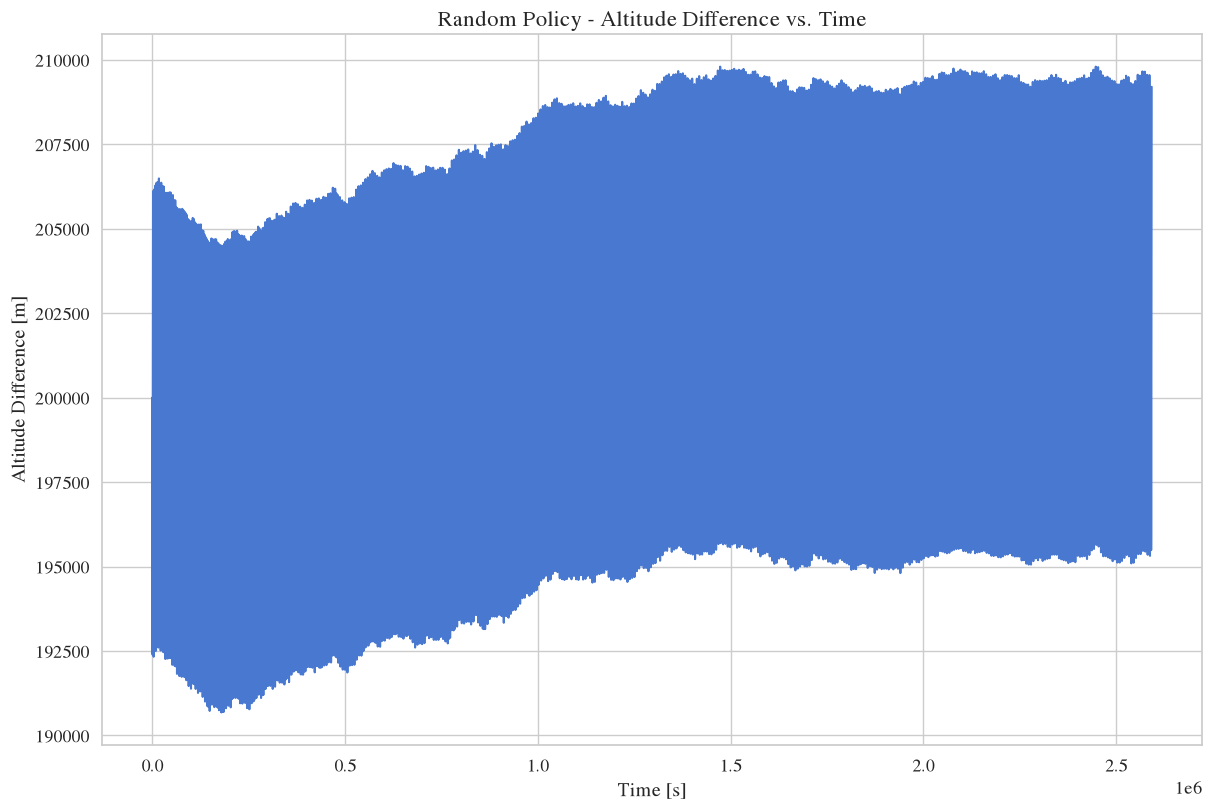

In [12]:
fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)
ax.set_title("Random Policy - Altitude Difference vs. Time")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Altitude Difference [m]")
ax.plot(randomTimes, randomAltDiffs)

fig.savefig(f"plots/{MODEL_NAME}_randomAltDiffs.pdf", bbox_inches="tight")
plt.show()

### Control Angles vs. Time

Shows the evolution of the cone and clock angles over time.

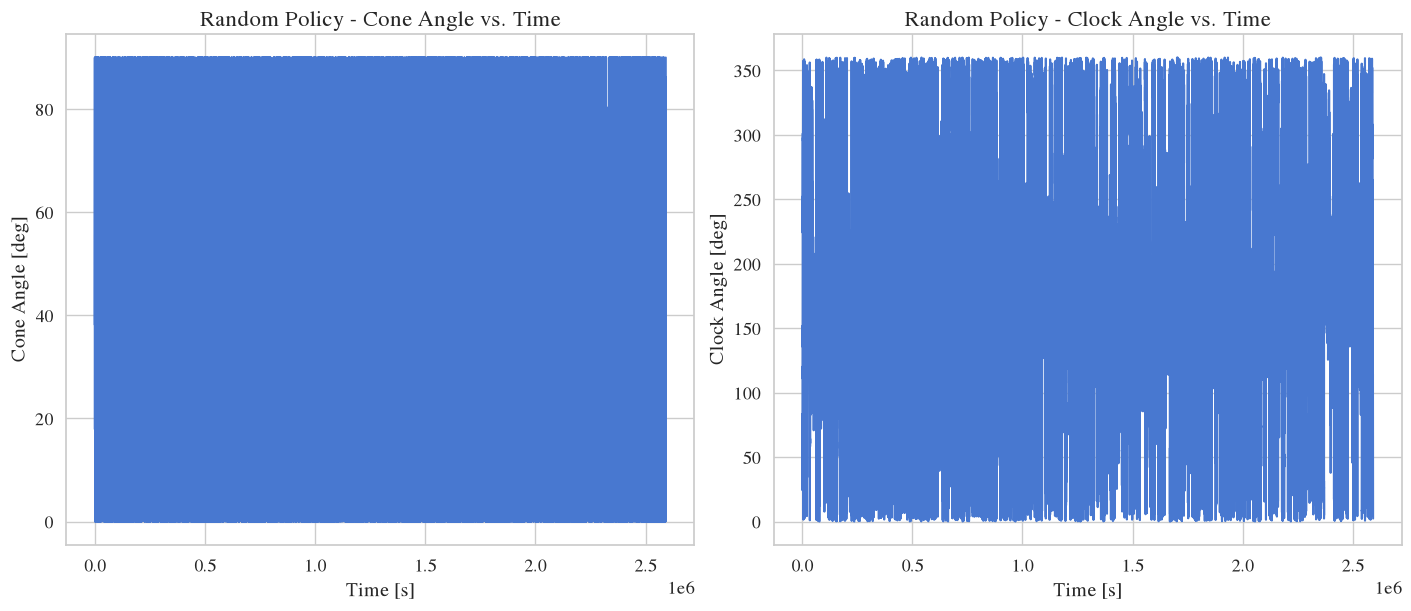

In [13]:
fig, (axCone, axClock) = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
axCone.set_title("Random Policy - Cone Angle vs. Time")
axCone.set_xlabel("Time [s]")
axCone.set_ylabel("Cone Angle [deg]")
axCone.plot(randomTimes, randomConeAngles)

axClock.set_title("Random Policy - Clock Angle vs. Time")
axClock.set_xlabel("Time [s]")
axClock.set_ylabel("Clock Angle [deg]")
axClock.plot(randomTimes, randomClockAngles)

fig.savefig(f"plots/{MODEL_NAME}_randomControlAngles.pdf", bbox_inches="tight")
plt.show()

## Initial Training

In [14]:
trainModel(seed=INITIAL_SEED)

trainingData = load_results(f"trainingData/{MODEL_NAME}/")
trainingData["steps"] = trainingData["l"].cumsum()
trainingRewards = trainingData["r"].to_numpy()
trainingLengths = trainingData["l"].to_numpy()
trainingSteps = trainingData["steps"].to_numpy()

 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3,047,424/3,024,000  [ 0:40:57 < 0:00:00 , 1,273 it/s ]

### Reward vs. Episode

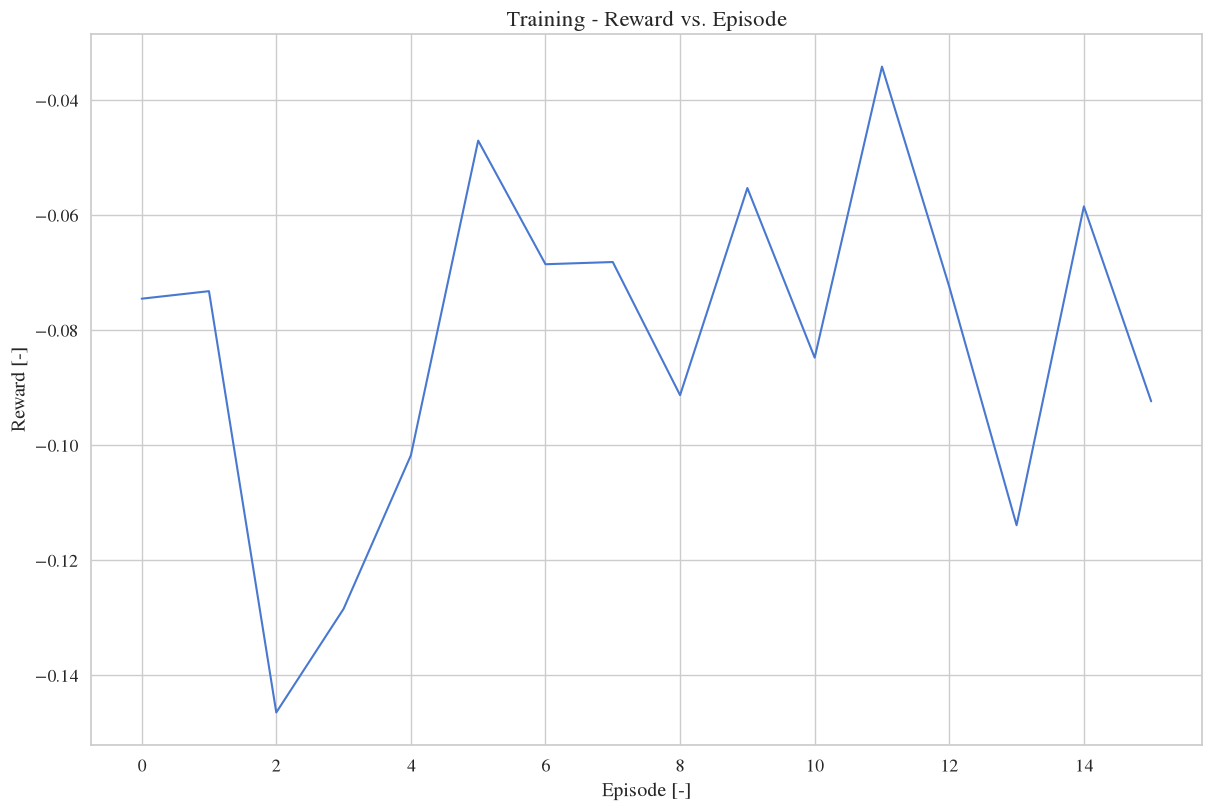

In [15]:
fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)
ax.set_title("Training - Reward vs. Episode")
ax.set_xlabel("Episode [-]")
ax.set_ylabel("Reward [-]")
ax.plot(trainingRewards)

fig.savefig(f"plots/{MODEL_NAME}_trainReward.pdf", bbox_inches="tight")
plt.show()

### Reward vs. Steps

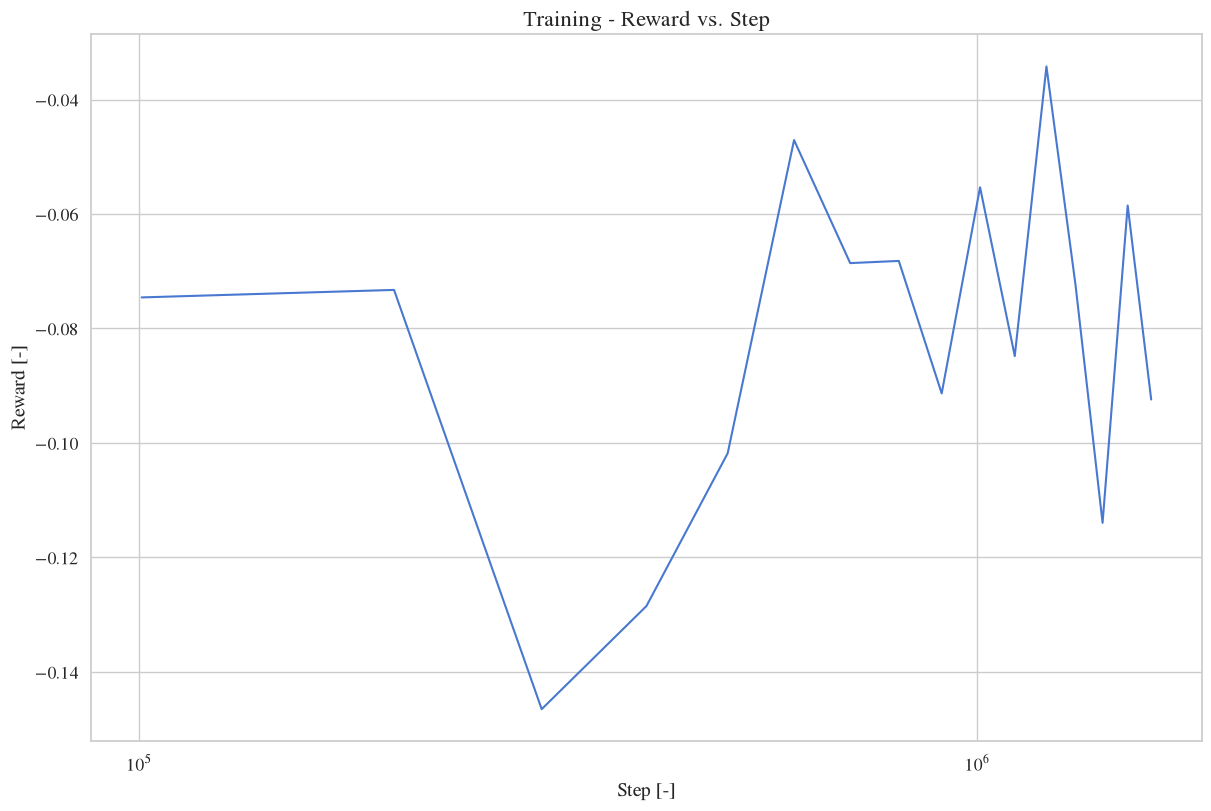

In [16]:
fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)
ax.set_title("Training - Reward vs. Step")
ax.set_xlabel("Step [-]")
ax.set_xscale("log")
ax.set_ylabel("Reward [-]")
ax.plot(trainingSteps, trainingRewards)

fig.savefig(f"plots/{MODEL_NAME}_trainRewardStep.pdf", bbox_inches="tight")
plt.show()

### Episode Length

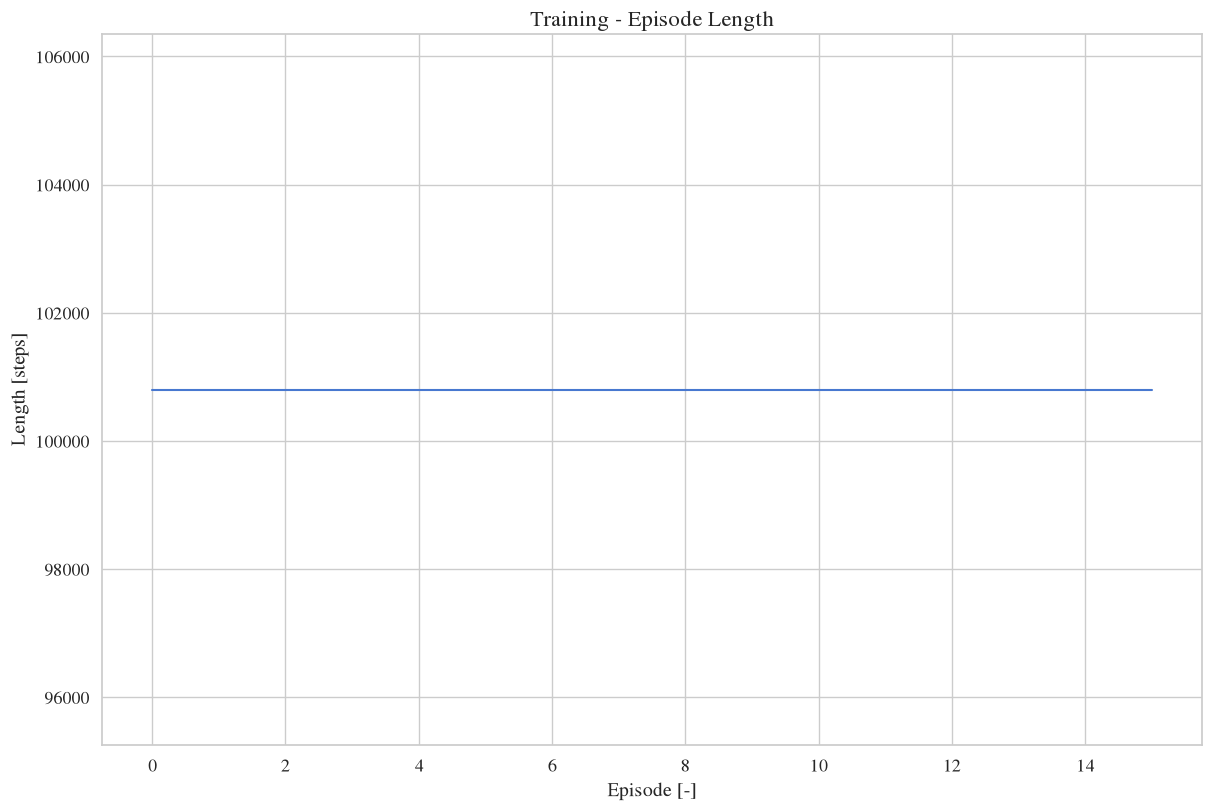

In [17]:
fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)
ax.set_title("Training - Episode Length")
ax.set_xlabel("Episode [-]")
ax.set_ylabel("Length [steps]")
ax.plot(trainingLengths)

fig.savefig(f"plots/{MODEL_NAME}_trainLength.pdf", bbox_inches="tight")
plt.show()

### Reward vs. Length

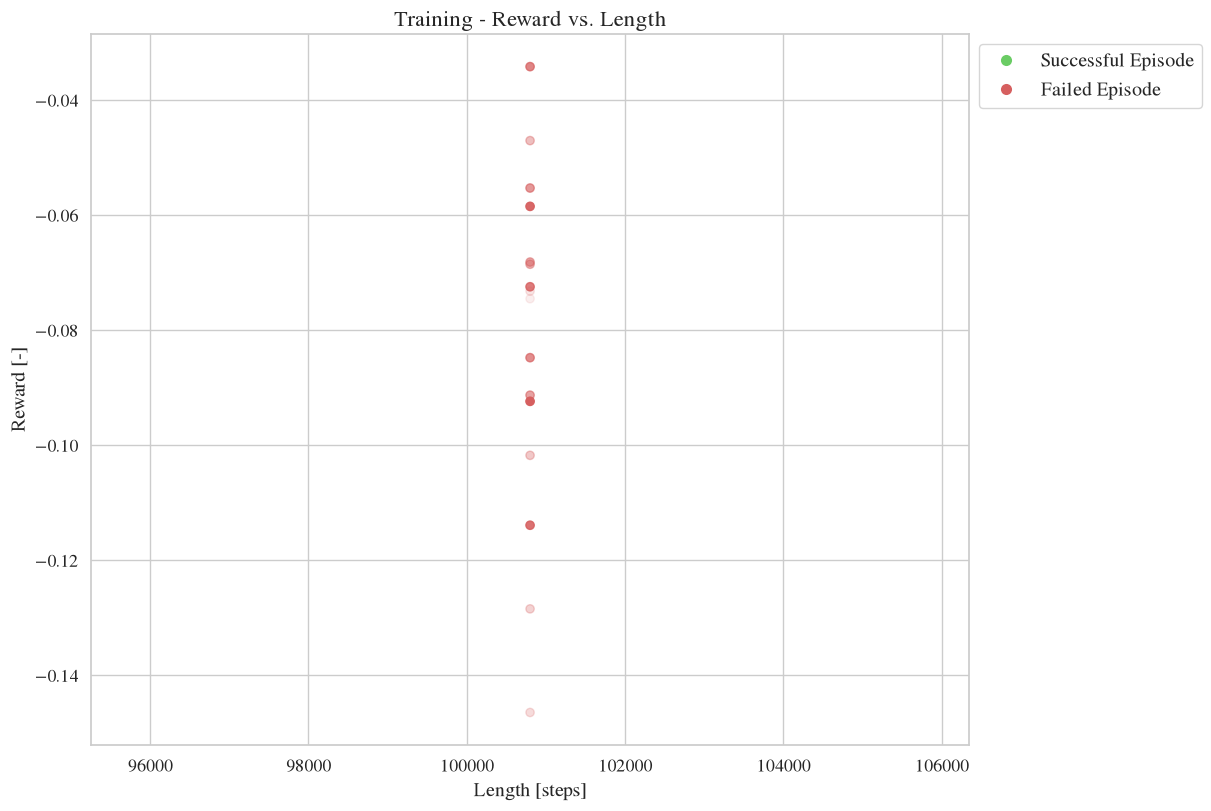

In [18]:
successfulRuns = trainingData["altDiff"] <= ALT_THRESHOLD
alphas = np.linspace(0.1, 1.0, len(trainingRewards))

fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)
ax.set_title("Training - Reward vs. Length")
ax.set_xlabel("Length [steps]")
ax.set_ylabel("Reward [-]")
if successfulRuns.any():
    ax.scatter(trainingLengths[successfulRuns], trainingRewards[successfulRuns], color="g", alpha=alphas[successfulRuns])
if (~successfulRuns).any():
    ax.scatter(trainingLengths[~successfulRuns], trainingRewards[~successfulRuns], color="r", alpha=alphas[~successfulRuns])

legendElements = [plt.Line2D([0], [0], marker="o", color="none", markerfacecolor="g", markeredgecolor="none", markersize=8, label="Successful Episode"),
                  plt.Line2D([0], [0], marker="o", color="none", markerfacecolor="r", markeredgecolor="none", markersize=8, label="Failed Episode")]
ax.legend(handles=legendElements, loc="upper left", bbox_to_anchor=(1, 1))
fig.savefig(f"plots/{MODEL_NAME}_trainRewardLength.pdf", bbox_inches="tight")
plt.show()

## Hyperparameter Tuning

Fine-tuning the model by finding the best set of model parameters to carry out the training. The objective function that includes the hyperparameters to tune and the ranges to tune them in is defined.

In [19]:
def objective(trial, tuningSeed: int, validationSeed: int, envName: str=ENVIRONMENT_NAME, nEnvs: int=N_ENVS, maxEpisodeTime: int=REDUCED_EPISODE_TIME):
    """
        Function used to select a set of hyperparameters and run the model.
    """
    learningRate = trial.suggest_float("learning_rate", 1E-06, 1E-03, log=True)
    nSteps = trial.suggest_categorical("n_steps", [512, 1024, 2048, 4096])
    batchSize = trial.suggest_categorical("batch_size", [32, 64, 128, 256, 512])
    nEpochs = trial.suggest_categorical("n_epochs", [5, 10, 15, 20])
    discountFactor = trial.suggest_float("gamma", 0.8, 0.9997)
    gaeLambda = trial.suggest_float("gae_lambda", 0.9, 1.0)
    clipRange = trial.suggest_float("clip_range", 0.1, 0.3)
    normalizeAdv = trial.suggest_categorical("normalize_advantage", [True, False])
    entropyCoeff = trial.suggest_float("ent_coef", 1E-08, 1E-02, log=True)
    valueCoeff = trial.suggest_float("vf_coef", 0.5, 1.0)

    env = make_vec_env(OrbitRaisingEnv, n_envs=nEnvs, vec_env_cls=SubprocVecEnv, env_kwargs={"maxTime": maxEpisodeTime, "altThreshold": ALT_THRESHOLD}, seed=tuningSeed) 

    model = PPO("MlpPolicy", env, learning_rate=learningRate, n_steps=nSteps, batch_size=batchSize, n_epochs=nEpochs, gamma=discountFactor, gae_lambda=gaeLambda, clip_range=clipRange, normalize_advantage=normalizeAdv, ent_coef=entropyCoeff, vf_coef=valueCoeff, seed=tuningSeed, device="cpu")

    checkpointEpisodes = 1 
    stepsPerCheckpoint = int(maxEpisodeTime/TIME_STEP) * checkpointEpisodes
    for i in range(5):  
        model.learn(total_timesteps=stepsPerCheckpoint, reset_num_timesteps=False, progress_bar=False)
        rewards, _ = testModel(model, validationSeed, tuning=True, N=5)
        trial.report(rewards.mean(), step=i)
        if trial.should_prune():
            env.close()
            raise optuna.TrialPruned()

    env.close()
    return rewards.mean()

objectiveWithArgs = lambda trial: objective(trial, tuningSeed=TUNING_SEED, validationSeed=VALIDATION_SEED, nEnvs=10)

The objective is passed to a study that aims to maximize the mean reward.

In [20]:
sampler = optuna.samplers.TPESampler(seed=TUNING_SEED, n_startup_trials=5)
study = optuna.create_study(direction="maximize", sampler=sampler, pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=1))
study.optimize(objectiveWithArgs, n_trials=10, n_jobs=2)

[I 2026-08-30 18:25:22,938] A new study created in memory with name: no-name-e5b64481-9c52-404a-8b89-f759caa7dabd
/home/abish/Vault/projects-gh/machine-learning/.ml/lib/python3.14/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/abish/Vault/projects-gh/machine-learning/.ml/lib/python3.14/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
/home/abish/Vault/projects-gh/machine-learning/.ml/lib/python3.14/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/abish/Vault/projects-gh/machine-learning/.ml/lib/python3.14/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym

The best parameters can then be examined.

In [21]:
print(f"Best Mean Reward: {study.best_value:.5f}")
bestParams = study.best_params
print("Achieved with the following parameters:")
for param, val in bestParams.items():
    print(f"    {param}: {val}")

Best Mean Reward: 0.00481
Achieved with the following parameters:
    learning_rate: 2.329867580955504e-05
    n_steps: 2048
    batch_size: 256
    n_epochs: 15
    gamma: 0.978028152774304
    gae_lambda: 0.9350165155610544
    clip_range: 0.18494671463159168
    normalize_advantage: False
    ent_coef: 0.0005942852646597667
    vf_coef: 0.982444988678401


## Training the Tuned Model

In [22]:
trainModel(seed=TRAINING_SEED, modelName=TUNED_MODEL_NAME, **bestParams)

tunedTrainingData = load_results(f"trainingData/{TUNED_MODEL_NAME}/")
tunedTrainingData["steps"] = tunedTrainingData["l"].cumsum()
tunedTrainingRewards = tunedTrainingData["r"].to_numpy()
tunedTrainingLengths = tunedTrainingData["l"].to_numpy()
tunedTrainingSteps = tunedTrainingData["steps"].to_numpy()

 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3,047,200/3,024,000  [ 0:27:04 < 0:00:00 , 2,199 it/s ]

### Reward vs. Episode

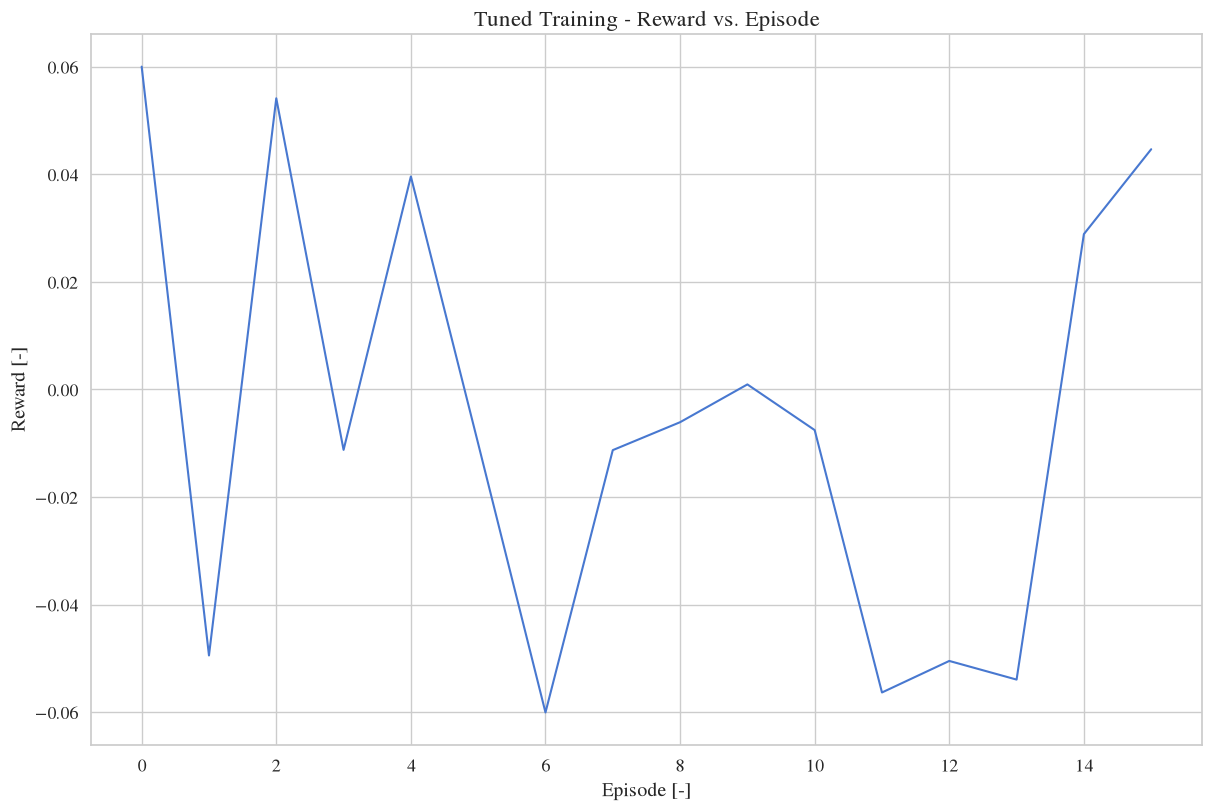

In [23]:
fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)
ax.set_title("Tuned Training - Reward vs. Episode")
ax.set_xlabel("Episode [-]")
ax.set_ylabel("Reward [-]")
ax.plot(tunedTrainingRewards)

fig.savefig(f"plots/{TUNED_MODEL_NAME}_trainReward.pdf", bbox_inches="tight")
plt.show()

### Reward vs. Step

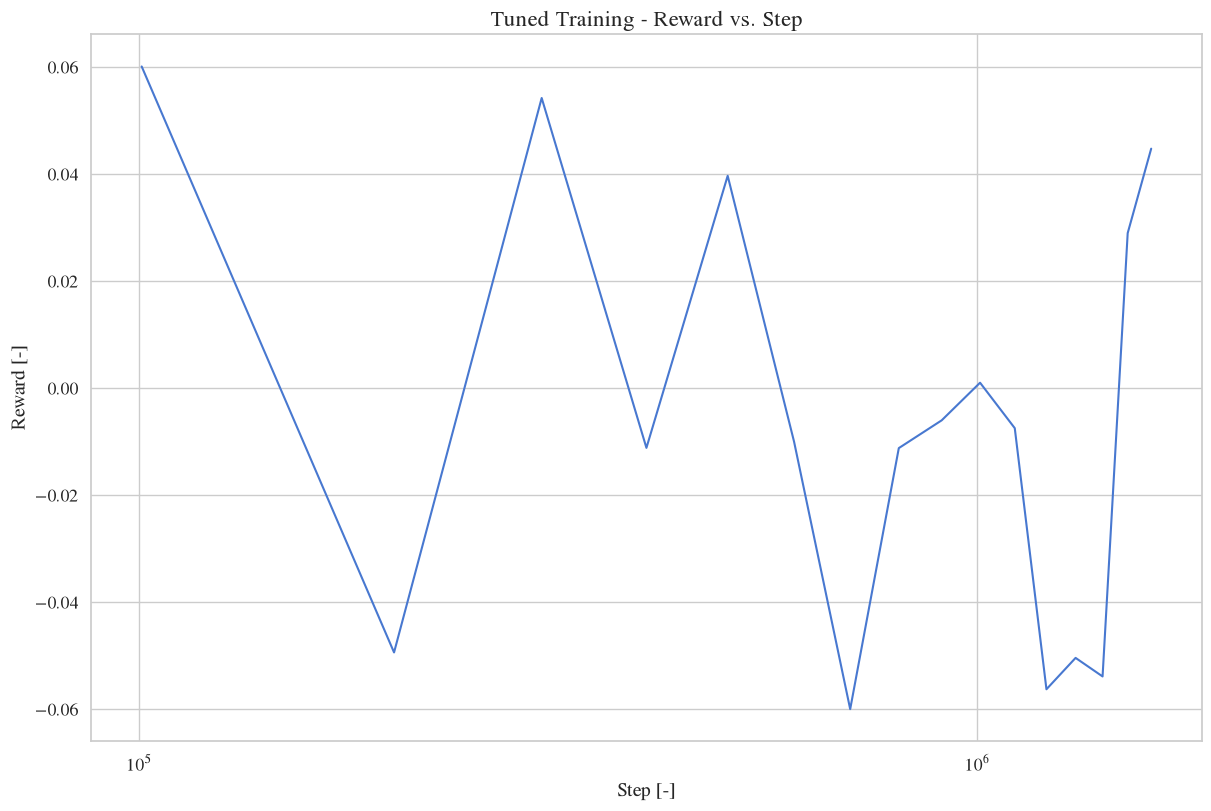

In [24]:
fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)
ax.set_title("Tuned Training - Reward vs. Step")
ax.set_xlabel("Step [-]")
ax.set_xscale("log")
ax.set_ylabel("Reward [-]")
ax.plot(tunedTrainingSteps, tunedTrainingRewards)

fig.savefig(f"plots/{TUNED_MODEL_NAME}_trainRewardStep.pdf", bbox_inches="tight")
plt.show()

### Episode Length

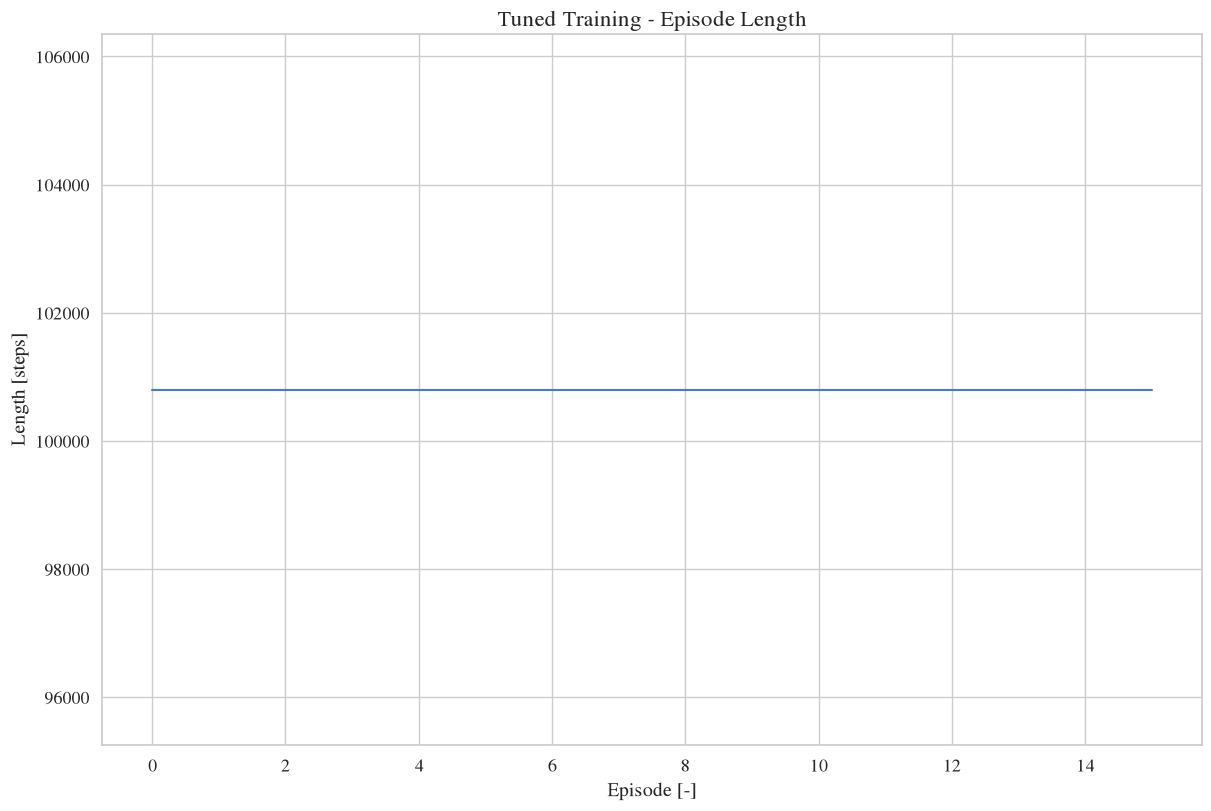

In [25]:
fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)
ax.set_title("Tuned Training - Episode Length")
ax.set_xlabel("Episode [-]")
ax.set_ylabel("Length [steps]")
ax.plot(tunedTrainingLengths)

fig.savefig(f"plots/{TUNED_MODEL_NAME}_trainLength.pdf", bbox_inches="tight")
plt.show()

### Reward vs. Length

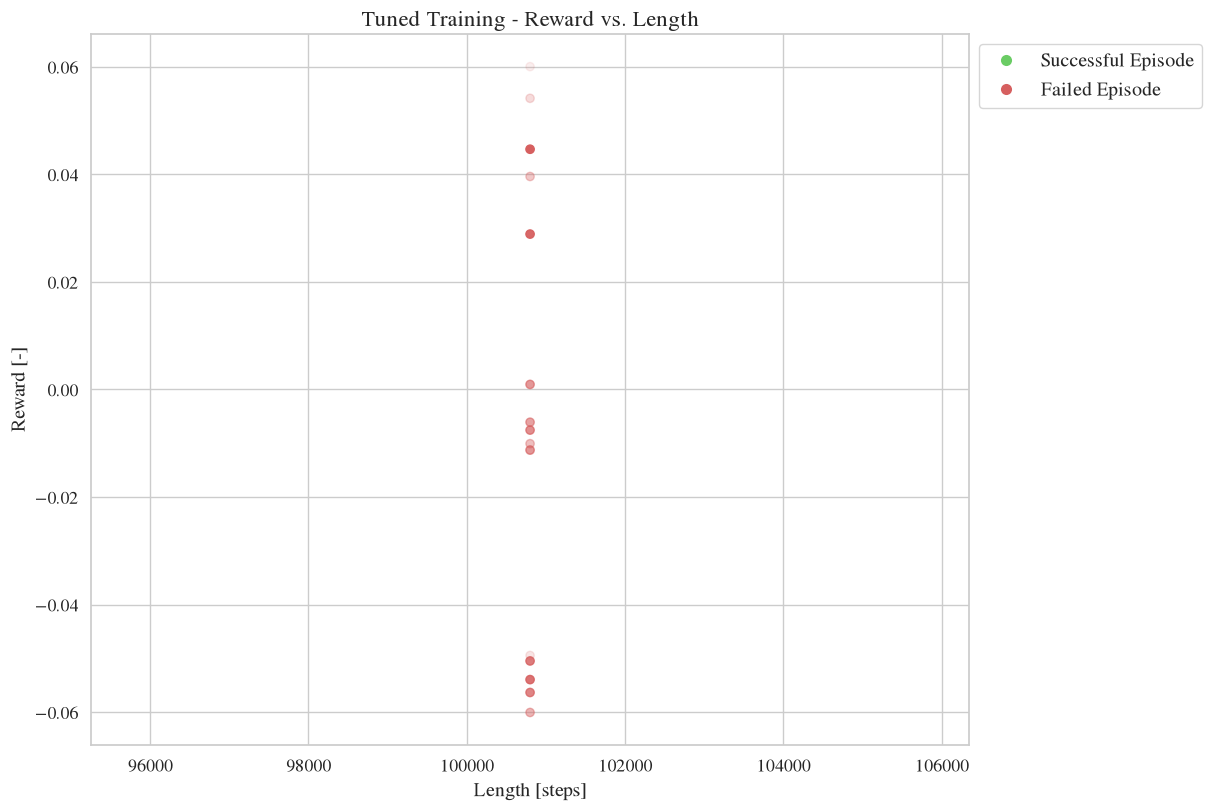

In [26]:
successfulRuns = tunedTrainingData["altDiff"] <= ALT_THRESHOLD
alphas = np.linspace(0.1, 1.0, len(tunedTrainingRewards))

fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)
ax.set_title("Tuned Training - Reward vs. Length")
ax.set_xlabel("Length [steps]")
ax.set_ylabel("Reward [-]")
if successfulRuns.any():
    ax.scatter(tunedTrainingLengths[successfulRuns], tunedTrainingRewards[successfulRuns], color="g", alpha=alphas[successfulRuns])
if (~successfulRuns).any():
    ax.scatter(tunedTrainingLengths[~successfulRuns], tunedTrainingRewards[~successfulRuns], color="r", alpha=alphas[~successfulRuns])

legendElements = [plt.Line2D([0], [0], marker="o", color="none", markerfacecolor="g", markeredgecolor="none", markersize=8, label="Successful Episode"),
                  plt.Line2D([0], [0], marker="o", color="none", markerfacecolor="r", markeredgecolor="none", markersize=8, label="Failed Episode")]
ax.legend(handles=legendElements, loc="upper left", bbox_to_anchor=(1, 1))
fig.savefig(f"plots/{TUNED_MODEL_NAME}_trainRewardLength.pdf", bbox_inches="tight")
plt.show()

## Testing the Tuned Model

In [27]:
tunedModel = PPO.load(TUNED_MODEL_NAME)
finalRewards, finalLengths, bestEpisode = testFinalModel(tunedModel, seed=TEST_SEED, tunedModelName=f"{TUNED_MODEL_NAME}_TEST", N=10)

testData = load_results(f"trainingData/{TUNED_MODEL_NAME}_TEST/")

/home/abish/Vault/projects-gh/machine-learning/.ml/lib/python3.14/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/home/abish/Vault/projects-gh/machine-learning/.ml/lib/python3.14/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/abish/Vault/projects-gh/machine-learning/.ml/lib/python3.14/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by cast

### Reward vs. Episodes

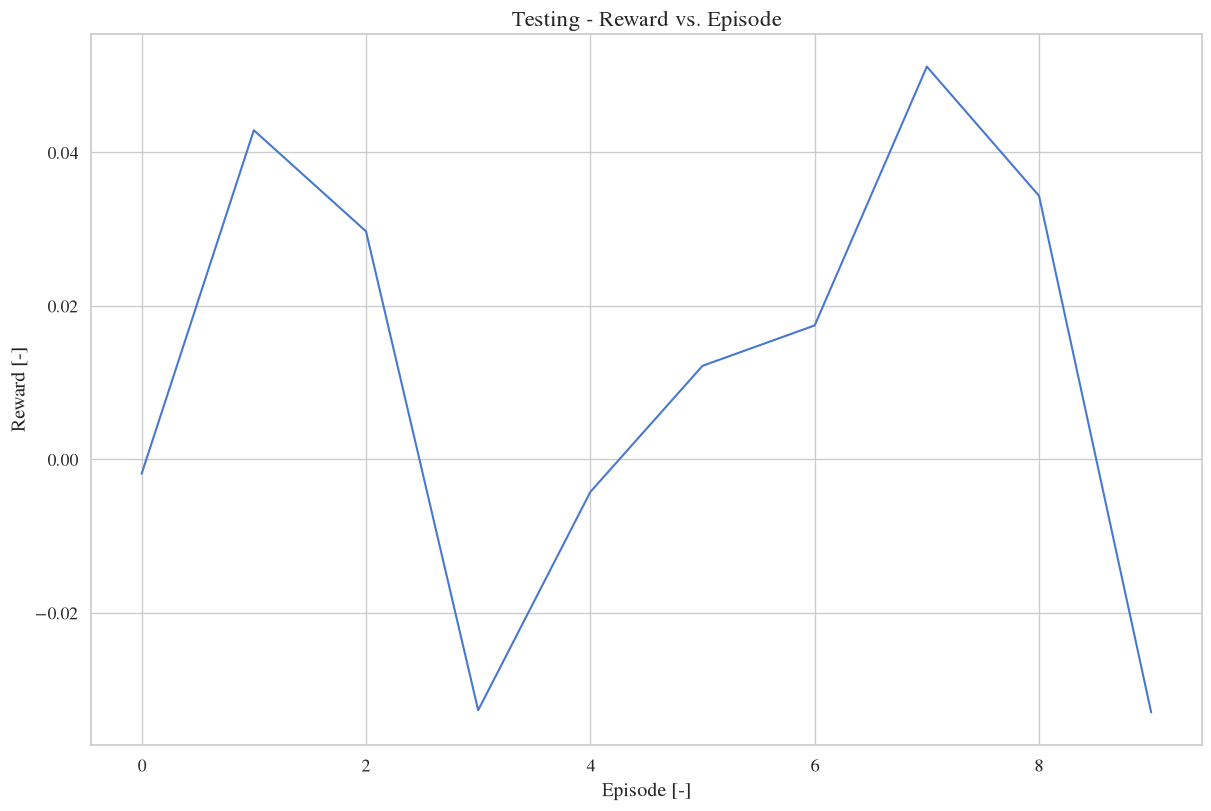

In [28]:
fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)
ax.set_title("Testing - Reward vs. Episode")
ax.set_xlabel("Episode [-]")
ax.set_ylabel("Reward [-]")
ax.plot(finalRewards)

fig.savefig(f"plots/{TUNED_MODEL_NAME}_testReward.pdf", bbox_inches="tight")
plt.show()

### Reward vs. Length

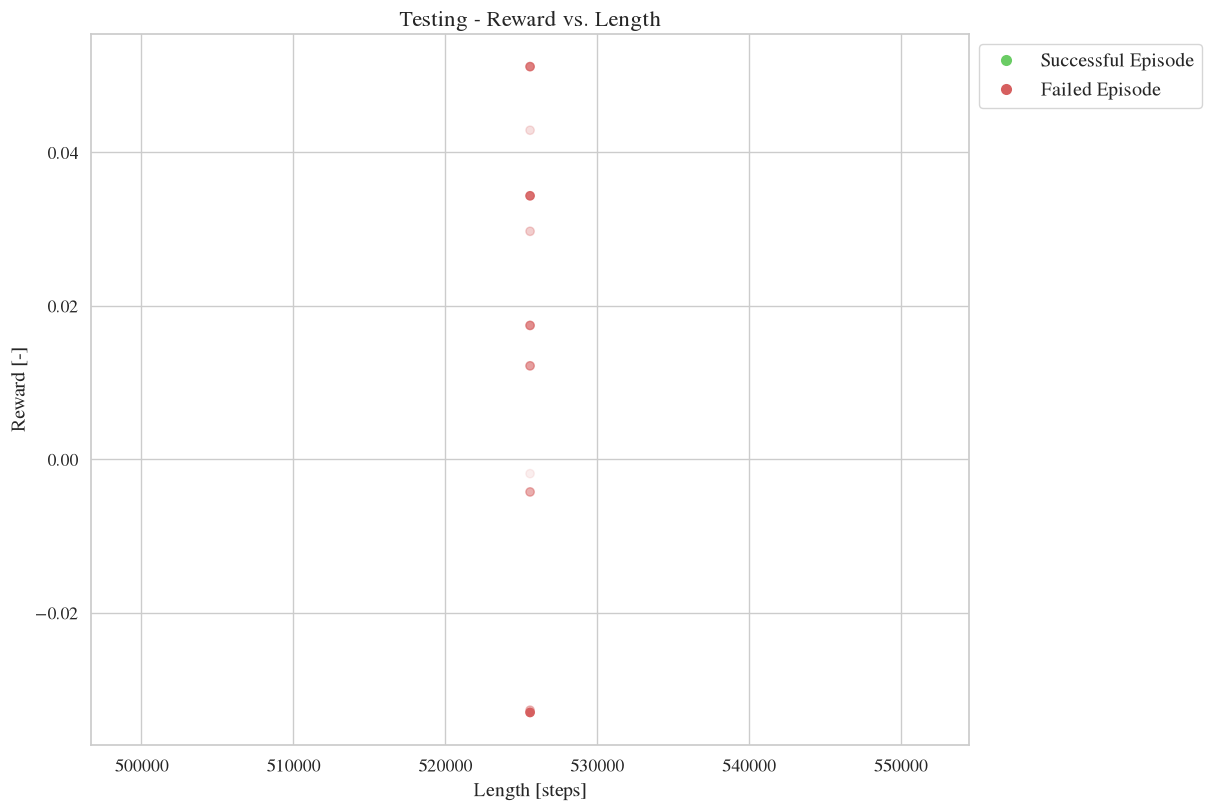

In [29]:
successfulRuns = testData["altDiff"] <= ALT_THRESHOLD
alphas = np.linspace(0.1, 1.0, len(finalRewards))

fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)
ax.set_title("Testing - Reward vs. Length")
ax.set_xlabel("Length [steps]")
ax.set_ylabel("Reward [-]")
if successfulRuns.any():
    ax.scatter(finalLengths[successfulRuns], finalRewards[successfulRuns], color="g", alpha=alphas[successfulRuns])
if (~successfulRuns).any():
    ax.scatter(finalLengths[~successfulRuns], finalRewards[~successfulRuns], color="r", alpha=alphas[~successfulRuns])

legendElements = [plt.Line2D([0], [0], marker="o", color="none", markerfacecolor="g", markeredgecolor="none", markersize=8, label="Successful Episode"),
                  plt.Line2D([0], [0], marker="o", color="none", markerfacecolor="r", markeredgecolor="none", markersize=8, label="Failed Episode")]
ax.legend(handles=legendElements, loc="upper left", bbox_to_anchor=(1, 1))
fig.savefig(f"plots/{TUNED_MODEL_NAME}_testRewardLength.pdf", bbox_inches="tight")
plt.show()

### Reward vs. Time

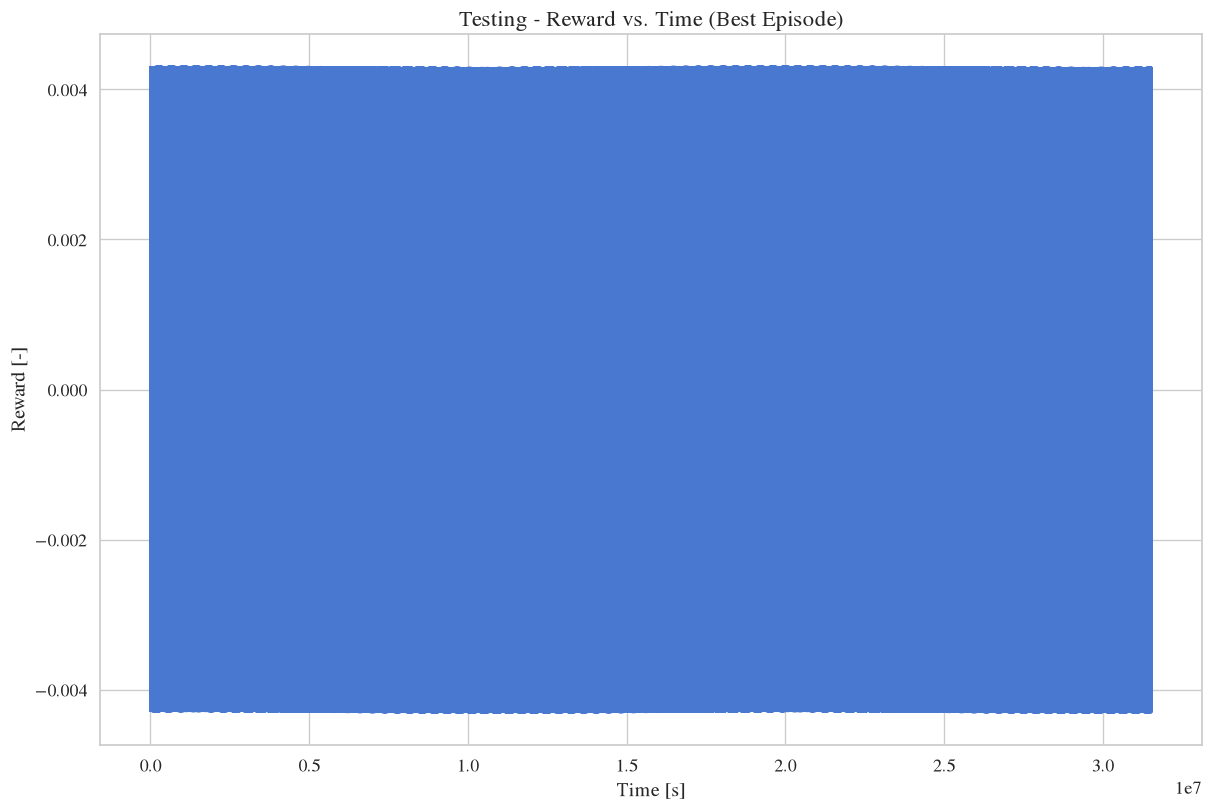

In [30]:
fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)
ax.set_title("Testing - Reward vs. Time (Best Episode)")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Reward [-]")
ax.plot(bestEpisode["time"], bestEpisode["reward"])

fig.savefig(f"plots/{TUNED_MODEL_NAME}_testBestReward.pdf", bbox_inches="tight")
plt.show()

### Altitude Difference vs. Time

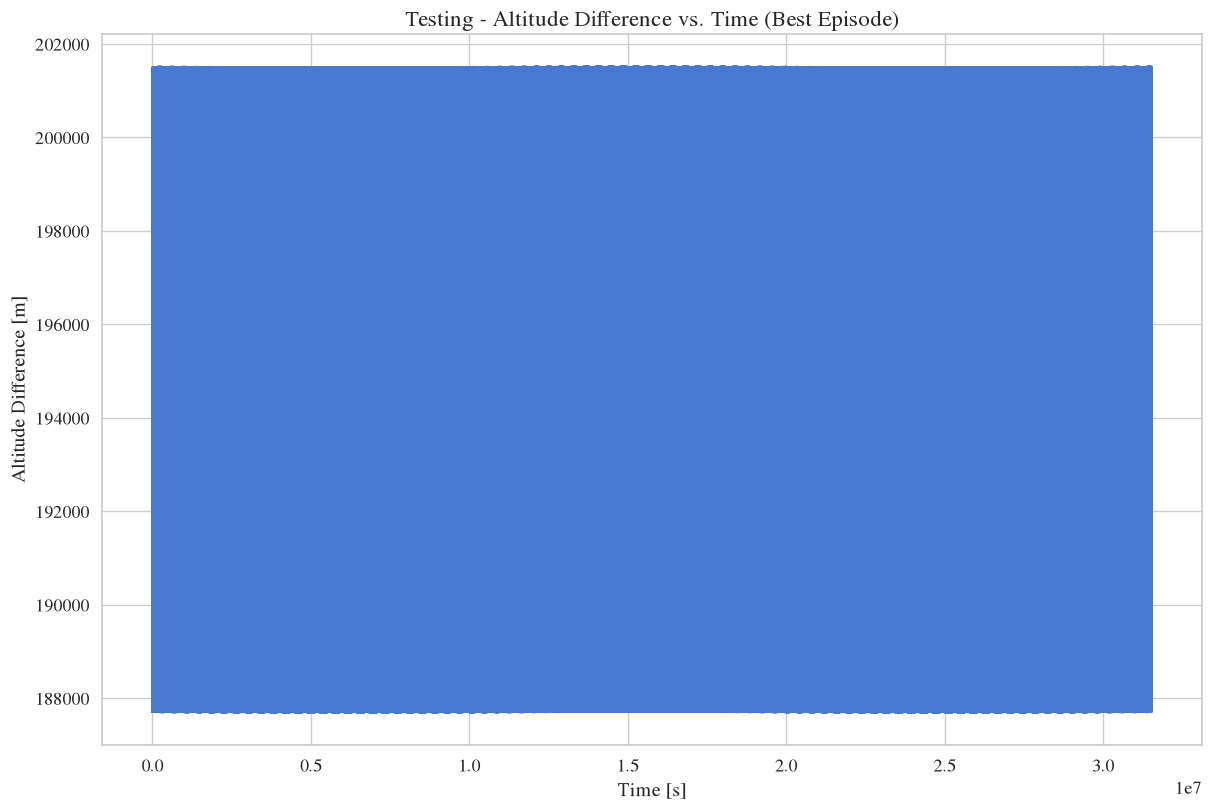

In [31]:
fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)
ax.set_title("Testing - Altitude Difference vs. Time (Best Episode)")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Altitude Difference [m]")
ax.plot(bestEpisode["time"], bestEpisode["altDiff"])

fig.savefig(f"plots/{TUNED_MODEL_NAME}_testBestAltDiffs.pdf", bbox_inches="tight")
plt.show()

### Control Angles vs. Time

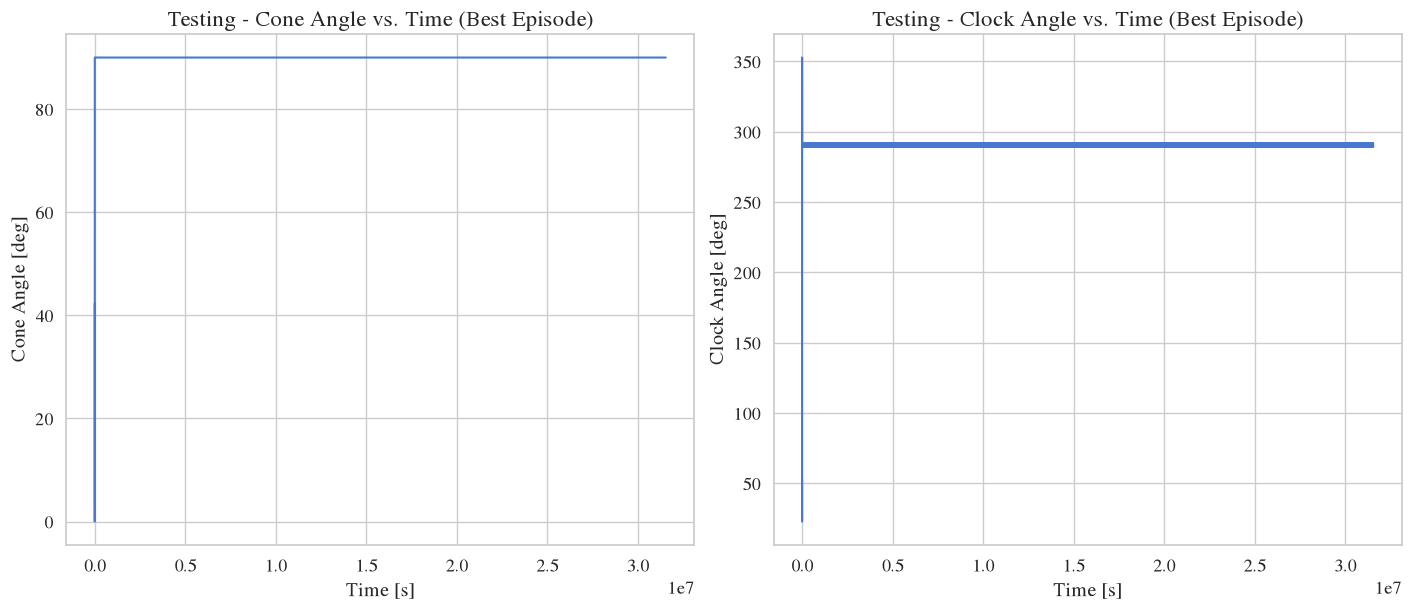

In [32]:
fig, (axCone, axClock) = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
axCone.set_title("Testing - Cone Angle vs. Time (Best Episode)")
axCone.set_xlabel("Time [s]")
axCone.set_ylabel("Cone Angle [deg]")
axCone.plot(bestEpisode["time"], np.rad2deg(bestEpisode["coneAngle"]))

axClock.set_title("Testing - Clock Angle vs. Time (Best Episode)")
axClock.set_xlabel("Time [s]")
axClock.set_ylabel("Clock Angle [deg]")
axClock.plot(bestEpisode["time"], np.rad2deg(bestEpisode["clockAngle"]))

fig.savefig(f"plots/{TUNED_MODEL_NAME}_testBestControlAngles.pdf", bbox_inches="tight")
plt.show()